In [19]:
import os
import sys
import pickle
import numpy as np
from numba import njit
import itertools as itt
import aerosandbox as asb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from Aircraft.Planform import Planform
from Aircraft.Fixed import Fixed
from Drag.Fuselage import Fuselage
from Drag.Bay import Bay
from Drag.LandingGear import LandingGear
from Aircraft.Aircraft import Aircraft
from global_parameters import Assumptions
from Requirements.FuelReq import FuelReq
from Requirements.LGReq import LGReq
from Requirements.MassReq import MassReq
from Requirements.MDReq import MDReq
from Requirements.EmpennageReq import EmpennageReq
from Requirements.Requirement import Requirement
from EmpennageSizing.TailFinder import TailFinder
from EmpennageSizing.CanardFinder import CanardFinder

from structural_analysis.Material import Material
from structural_analysis.iterative_planform_sizing import size_planform, find_planform_mass_cg

In [20]:
assumptions = Assumptions()

#TODO load the fuselage here
with open("pickles/fixed_pickle.pcl", "rb") as f:
    fixed:Fixed = pickle.load(f)

print(fixed.x_cg_max, fixed.x_cg_min, fixed.x_LE_wing, fixed.z_cg, fixed.z_tail_cone)
fixed.x_LE_wing = 1.255
delta_z = 0.01
fixed.z_tail_cone += delta_z
fixed.z_cg += delta_z
print(fixed.z_cg, fixed.z_tail_cone)
fixed.fuel_mass = 13.54
fixed.x_cg_min = 1.378 #m #1.381
fixed.x_cg_max = 1.381 #m # 1.378
fixed.mass = 40.782#kg 
fixed.fuselage.diameter_max = 0.315

for component in fixed.drag_components(False):
    component.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
    component.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
    component.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
for component in fixed.drag_components(True):
    component.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)

1.3589152301106575 1.271545179962353 1.4400000000000002 0.17957635338517247 0.11000000000000004
0.18957635338517248 0.12000000000000004


# Defining the standard aircraft with the standard planform
To be used when ppl don't wanna build their own planform

In [21]:
standard_wing = Planform(aspect_ratio=27, span=3.4, sweep_quarter_deg=15., taper=.3, thickness_to_chord=0.12, cm_quarter_chord=0,
                         wetted_surface_ratio=1.07, interference_factor=1.0, clmax=1.22, flap=False)

In [22]:
assumptions = Assumptions()

go_around_atmosphere = asb.Atmosphere(assumptions.altitude_go_round)
sea_level_atmosphere = asb.Atmosphere()

standard_wing.add_cache_entry('cruise', assumptions.mach_cruise, assumptions.altitude_cruise)
standard_wing.add_cache_entry('mach_max', assumptions.mach_max, assumptions.altitude_mach_max)
#NOTE: not fully technically correct but prevents coupling which would be problematic, acceptable as CD0 dept. on mach is small @ low mach
standard_wing.add_cache_entry('go_around', assumptions.airspeed_approach / go_around_atmosphere.speed_of_sound(), assumptions.altitude_go_round)
standard_wing.add_cache_entry('takeoff', assumptions.airspeed_approach / sea_level_atmosphere.speed_of_sound(), 0.)

In [23]:
material_skin = Material(assumptions.cfrp_density, elastic_modulus=assumptions.cfrp_Young_modulus, 
                         poisson_ratio=assumptions.cfrp_poisson, shear_modulus=assumptions.cfrp_Young_modulus / 2 / (1 + assumptions.cfrp_poisson),
                         yield_strength=assumptions.cfrp_yield_strength, fracture_strength=assumptions.cfrp_yield_strength)

fuselage_diameter = fixed.fuselage.diameter_max
#size_planform(planform=standard_wing, thicknesses=assumptions.allowable_thicknesses, fuselage_diameter=fuselage_diameter, material_skin=material_skin, density_core=assumptions.foam_denisty)
pf_mass, pf_xcg = find_planform_mass_cg(standard_wing, 0.0025, assumptions.foam_denisty, assumptions.cfrp_density, 100) 
standard_wing.mass_cache = pf_mass
standard_wing.x_cg_cache = pf_xcg
print(standard_wing.mass_cache)  

4.781762892775701


In [24]:
print(standard_wing.mass_cache, standard_wing.x_cg_cache, fixed.fuel_mass)

4.781762892775701 0.2645443221402019 13.54


# We consider the thing to be tailed

Stresses 10625717.154143251, 20546775.88690496, 0.0004
Stresses 7109210.46879422, 14093939.333535528, 0.0005959183673469389
Stresses 6212473.4766750075, 17694390.599531714, 0.0004
Stresses 4113223.1168574053, 11861627.745257156, 0.0005959183673469389
Iteration 0: Sh_S=0.10482323859339097, lh=7.500120564189571, x_ac_h=9.204079795028766, x_cg=(2.0496387716726967, 2.068701210814064), Local_ac: 0.0577318783205846
Stresses 10877981.017963184, 20696627.13186164, 0.0004
Stresses 7277987.261863564, 14188065.365896452, 0.0005959183673469389
Stresses 6368902.646694996, 17349606.90125038, 0.0004
Stresses 4219545.522631464, 11635579.143381348, 0.0005959183673469389
Iteration 1: Sh_S=0.10559382485806156, lh=7.510083743480382, x_ac_h=9.214042974319577, x_cg=(2.0528732025787257, 2.071928558927088), Local_ac: 0.05910775633441691
Stresses 10917742.011805627, 20725203.499916747, 0.0004
Stresses 7304589.300396018, 14206324.630986638, 0.0005959183673469389
Stresses 6393542.477073747, 17559853.302628968, 0

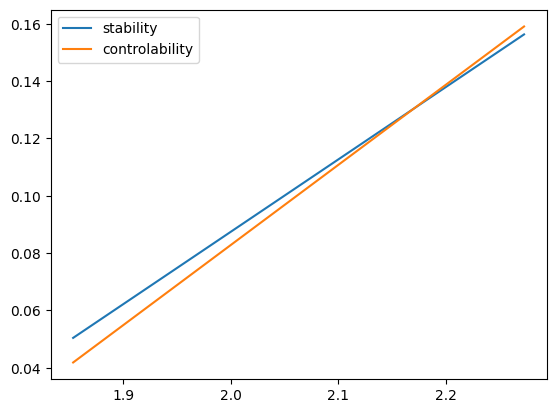

0.10573668139380375


In [25]:
tail = TailFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_h=3., taper_h=.7, Sv_S=0.2).find_planforms(standard_wing, print_=True, plot=True)

print(tail[0].wing_area / standard_wing.wing_area)

In [26]:
for t in tail:
    t.add_cache_entry('cruise', assumptions.mach_cruise, assumptions.altitude_cruise)
    t.add_cache_entry('mach_max', assumptions.mach_max, assumptions.altitude_mach_max)
#NOTE: not fully technically correct but prevents coupling which would be problematic, acceptable as CD0 dept. on mach is small @ low mach
    t.add_cache_entry('go_around', assumptions.airspeed_approach / go_around_atmosphere.speed_of_sound(), assumptions.altitude_go_round)
    t.add_cache_entry('takeoff', assumptions.airspeed_approach / sea_level_atmosphere.speed_of_sound(), 0.)

In [27]:
ac = Aircraft(fixed, [standard_wing] + tail)
print(standard_wing.wing_area)
print(fixed.x_LE_wing)


0.4281481481481481
1.255


In [39]:
for acp in ac.planforms:
    print(acp.mass_cache)

print(ac.fixed.x_cg_min, ac.fixed.x_cg_max, ac.fixed.x_LE_wing)

x_LE_vt = fixed.x_LE_tail - tail[1].span / 2 * np.tan(tail[1].sweep_LE_rad)

x_cg_min = (fixed.x_cg_min * fixed.mass + standard_wing.mass_cache * (fixed.x_LE_wing + standard_wing.x_cg_cache) + tail[0].mass_cache * (fixed.x_LE_tail +tail[0].x_cg_cache) + tail[1].mass_cache * (x_LE_vt +tail[1].x_cg_cache)) / ac.total_mass()
x_cg_max = (fixed.x_cg_max * fixed.mass + standard_wing.mass_cache * (fixed.x_LE_wing + standard_wing.x_cg_cache) + tail[0].mass_cache * (fixed.x_LE_tail +tail[0].x_cg_cache) + tail[1].mass_cache * (x_LE_vt +tail[1].x_cg_cache)) / ac.total_mass()

print(f"cg range: {x_cg_min, x_cg_max}")

4.781762892775701
0.1672045662715506
0.7656294111041528
1.378 1.381 1.255
cg range: (1.413799370054346, 1.416430659400998)


# Requirement check for the aircraft

In [29]:
requirements:list[Requirement] = [
    MassReq(50.),
    MDReq(mtom=ac.total_mass(), plot=True),
    FuelReq(print_=True),
    LGReq(),
    EmpennageReq(),
]

requirement_labels = [
    "MTOM",
    "Matching Diagram",
    "Fuel",
    "Landing Gear",
    "Empennage Requirement"
]

6.884043702509126
46.4965968701514 [4.781762892775701, 0.1672045662715506, 0.7656294111041528]


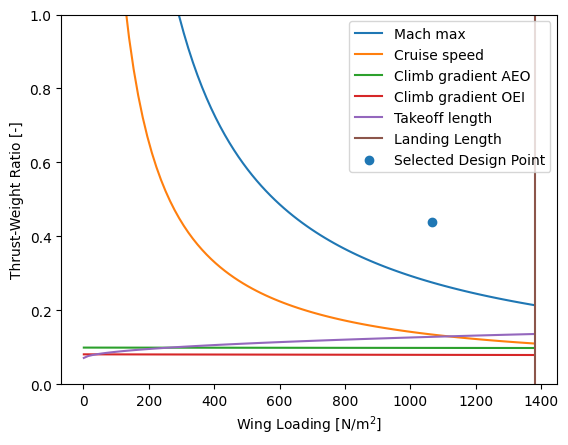

In [30]:
failed_reqs = list()
for requirement, label in zip(requirements, requirement_labels):
    if not requirement.assess(ac):
        failed_reqs.append(label)

if len(failed_reqs):
    print(f"ac mass: {ac.total_mass()}, {ac.planforms[0].oswald}")
    print(f"MainWing: AR={ac.planforms[0].aspect_ratio}, tc={ac.planforms[0].thickness_to_chord}, sweep={np.rad2deg(ac.planforms[0].sweep_quarter_rad)} deg, cmac={ac.planforms[0].cm_quarter_chord}")
    print(f"Failed: {failed_reqs}")
    print()


print(ac.total_mass(), [pf.mass_cache for pf in ac.planforms])

In [35]:
print("Standard Planform:")
print(f"Tail properties: cr={ac.planforms[1].c_root}, b/2={ac.planforms[1].half_span}, sweep={np.rad2deg(ac.planforms[1].sweep_LE_rad)}, ct={ac.planforms[1].c_tip}, x_LE_root={fixed.x_LE_tail}")
print(f"Vertical tail properties: cr={ac.planforms[2].c_root}, b/2={ac.planforms[2].half_span}, ct={ac.planforms[2].c_tip}, sweep={np.rad2deg(ac.planforms[2].sweep_LE_rad)}")
print(f"xcg_rang: {fixed.x_cg_min}, {fixed.x_cg_max}")


Standard Planform:
Tail properties: cr=0.1445207876158203, b/2=0.18426400421017086, sweep=18.09597980219284, ct=0.1011645513310742, x_LE_root=2.4683173177143614
Vertical tail properties: cr=0.24086797935970053, b/2=0.4443805163375125, ct=0.14452078761582032, sweep=32.27459633762159
xcg_rang: 1.378, 1.381


In [32]:
#TODO: ctrl surface sizing

## V&V stall speed

In [33]:
print(fixed.z_tail_cone - assumptions.main_gear_diameter_wheel /2)
print(f"CL_max = {ac.planforms[0].positive_C_L_max}")
print(f"Alpha_stall = {np.rad2deg(ac.planforms[0].positive_C_L_max / ac.planforms[0].CL_alpha)}")
print(f"Vstall={np.sqrt(ac.wing_loading()*2/1.225/ac.planforms[0].positive_C_L_max)}")


0.07750000000000004
CL_max = 1.0605865572653972
Alpha_stall = 10.706500190728967
Vstall=40.49000039583


In [34]:
print(ac.CD0_takeoff, ac.planforms[0].oswald, fixed.fuselage.characteristic_length, fixed.fuselage.diameter_max, fixed.x_tail_cone)
print(0.5*np.sqrt(np.pi*27*ac.planforms[0].oswald/ac.CD0_takeoff))

0.05085218576739342 0.6920992767461398 2.7 0.315 2.3524759765715424
16.988545905284983
